In [5]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

match = pd.read_csv("data/gold_match.csv")
tickets = pd.read_csv("data/gold_match_tickets.csv")
context = pd.read_csv("data/gold_match_context.csv")
trends = pd.read_csv("data/gold_google_trends_daily.csv")
articles = pd.read_csv("data/gold_belga_press_articles.csv", engine="python", on_bad_lines="skip")

match = match[match["is_home_match"] == True]

trends_agg = trends.groupby("match_id")["ohl_interest"].mean().reset_index()

articles_agg = articles.groupby("match_id").size().reset_index(name="num_articles")

df = match.merge(tickets, on="match_id")
df = df.merge(context, on="match_id")
df = df.merge(trends_agg, on="match_id")
df = df.merge(articles_agg, on="match_id")

df["ohl_interest"] = df["ohl_interest"].fillna(0)
df["num_articles"] = df["num_articles"].fillna(0)


In [6]:
corr_target = df.corr(numeric_only=True)["tickets_scanned"].sort_values(ascending=False)

print(corr_target)

tickets_scanned                  1.000000
tickets_trib1                    0.713877
tickets_sold_total               0.517182
tickets_trib3                    0.499295
tickets_sold_b2c                 0.430666
tickets_trib4                    0.349030
matchday                         0.327908
num_articles                     0.251471
tickets_sold_b2b                 0.235197
weekday                          0.153500
is_weekend                       0.116684
weather_windspeed_max_kmh        0.116283
promo_1plus1_tickets             0.111199
seasonpass_holders               0.108242
weather_code                     0.097277
ohl_interest                     0.081318
tickets_trib2_uit                0.051152
weather_score                    0.039623
weather_temp_deviation           0.033630
tickets_trib2_thuis              0.008629
is_school_holiday_flanders      -0.012012
weather_temp_min_c              -0.029289
promo_bring_a_friend_tickets    -0.030247
weather_rain_mm                 -0

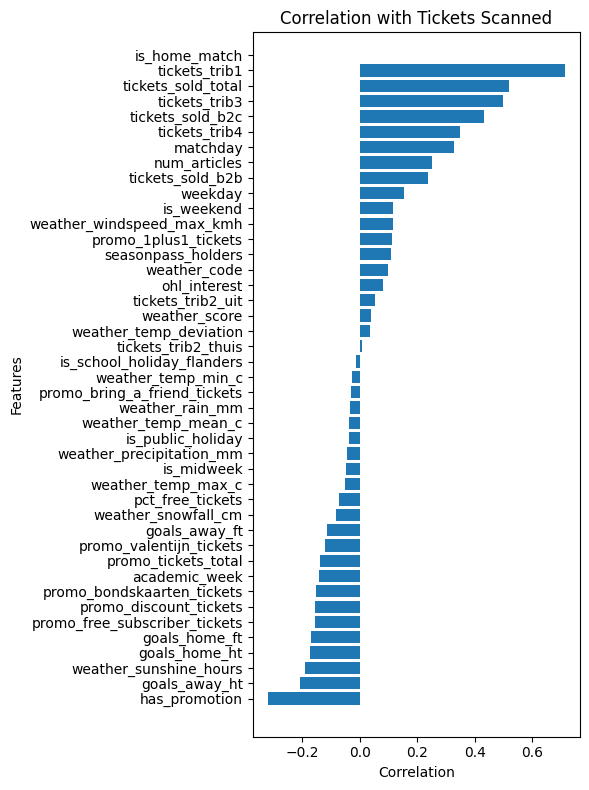

In [7]:
import matplotlib.pyplot as plt

corr_target = df.corr(numeric_only=True)["tickets_scanned"].drop("tickets_scanned").sort_values()

plt.figure(figsize=(6, 8))
plt.barh(corr_target.index, corr_target.values)
plt.title("Correlation with Tickets Scanned")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.tight_layout()
plt.show()